## Let´s go to models

In [1]:
import sqlite3
import pandas as pd
import numpy as np
import os
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt

base_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))
db_path = os.path.join(base_dir, "data", "electricity.db")
conn = sqlite3.connect(db_path)

df = pd.read_sql("""
    SELECT * FROM omie_features_historic
    ORDER BY datetime
""", conn)

conn.close()
print(df.shape)

(51426, 21)


In [2]:
features = [
    "hour_sin", "hour_cos",
    "doy_sin", "doy_cos",
    "weekday_sin", "weekday_cos",
    "is_weekend",
    "post_excepcion",
    "lag_1", "lag_24", "lag_168",
    "rolling_mean_24", "rolling_mean_168"
]

target = "price_es"

X = df[features]
y = df[target]

# Split temporal 80/20
split = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

print(f"Train: {len(X_train)} filas")
print(f"Test: {len(X_test)} filas")
print(f"Train hasta: {df['datetime'].iloc[split-1]}")
print(f"Test desde: {df['datetime'].iloc[split]}")

Train: 41140 filas
Test: 10286 filas
Train hasta: 2023-10-23 08:00:00
Test desde: 2023-10-23 09:00:00


Hmmm, quizás mejor cortar a final del 2023 y que prediga todo 2024. Así es más limpio

In [3]:
# Split por fecha en lugar de porcentaje
split_date = "2024-01-01"

df["datetime"] = pd.to_datetime(df["datetime"])

train_mask = df["datetime"] < split_date
test_mask = df["datetime"] >= split_date

X_train = X[train_mask]
X_test = X[test_mask]
y_train = y[train_mask]
y_test = y[test_mask]

print(f"Train: {len(X_train)} filas — hasta {df['datetime'][train_mask].max()}")
print(f"Test: {len(X_test)} filas — desde {df['datetime'][test_mask].min()}")

Train: 42811 filas — hasta 2023-12-31 23:00:00
Test: 8615 filas — desde 2024-01-01 00:00:00


### Modelos como con un año

In [4]:
# Baseline
baseline_pred = X_test["lag_24"]
baseline_mae = mean_absolute_error(y_test, baseline_pred)
print(f"Baseline (lag_24): MAE = {baseline_mae:.2f}")

# Ridge
ridge = Ridge()
ridge.fit(X_train, y_train)
ridge_pred = ridge.predict(X_test)
ridge_mae = mean_absolute_error(y_test, ridge_pred)
print(f"Ridge: MAE = {ridge_mae:.2f}")

# Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_mae = mean_absolute_error(y_test, rf_pred)
print(f"Random Forest: MAE = {rf_mae:.2f}")

Baseline (lag_24): MAE = 18.55
Ridge: MAE = 7.85
Random Forest: MAE = 6.93


Ahora el baseline del Lag_24 tiene un error mayor. Que para el año entero. Eso se debe a que ahora gran parte del modelo esta entranado sin volatilidad y predice un año con mucha volatilidad. Eso no pasaba cuando tambien se entrenaba en un año con volatilidad

In [5]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    random_state=42,
    verbosity=0
)
xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)
xgb_mae = mean_absolute_error(y_test, xgb_pred)
print(f"XGBoost: MAE = {xgb_mae:.2f}")

# Comparar train vs test para ver overfitting
mae_train = mean_absolute_error(y_train, xgb.predict(X_train))
print(f"XGBoost train MAE = {mae_train:.2f}")

XGBoost: MAE = 5.86
XGBoost train MAE = 3.60


Ahora sí! Esta vez el MAE de la predicción es 5.86 (mejorando Random Forest) y el del train set es de 3.60. Es un overfitting razonable.

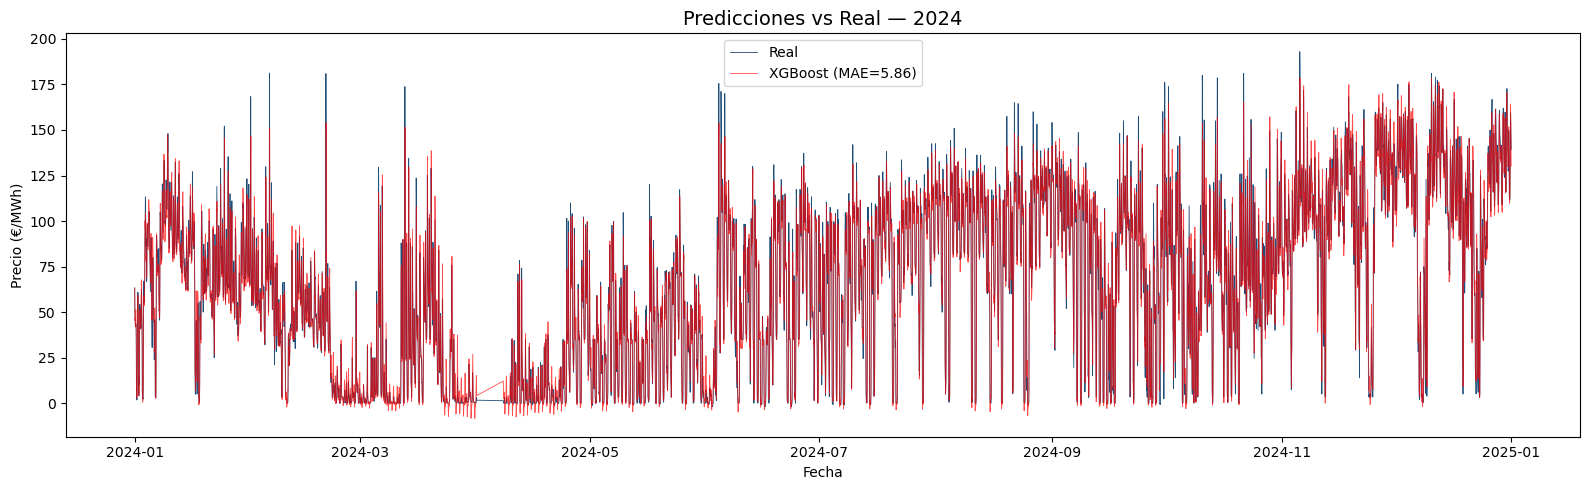

In [6]:
datetime_test = pd.to_datetime(df["datetime"][test_mask]).reset_index(drop=True)
plt.close('all')
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(datetime_test, y_test.reset_index(drop=True),
        label="Real", color="#1F4E79", linewidth=0.6)
ax.plot(datetime_test, xgb_pred,
        label=f"XGBoost (MAE={xgb_mae:.2f})", color="red", linewidth=0.6, alpha=0.7)
ax.set_title("Predicciones vs Real — 2024", fontsize=14)
ax.set_xlabel("Fecha")
ax.set_ylabel("Precio (€/MWh)")
ax.legend()
plt.tight_layout()
plt.savefig("../outputs/predicciones_vs_real_historico.png", dpi=150)
plt.show()

Un poco dificil de comparar para un año entero. Veamos un solo mes, por ejempo enero

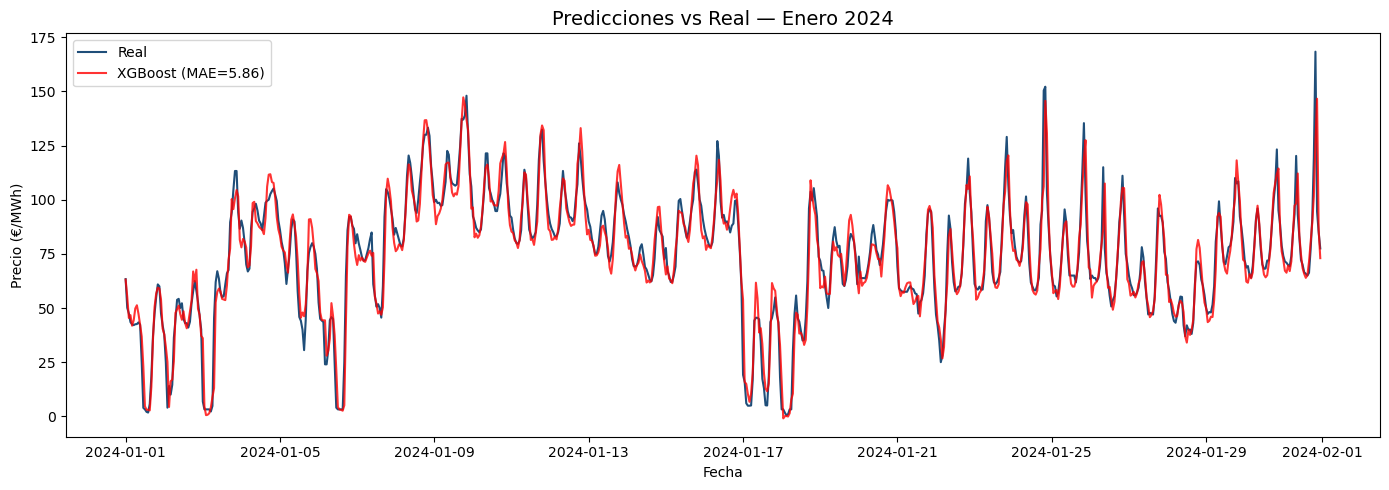

In [7]:
mask_enero = (datetime_test >= "2024-01-01") & (datetime_test < "2024-02-01")

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(datetime_test[mask_enero], y_test.reset_index(drop=True)[mask_enero],
        label="Real", color="#1F4E79", linewidth=1.5)
ax.plot(datetime_test[mask_enero], xgb_pred[mask_enero],
        label=f"XGBoost (MAE={xgb_mae:.2f})", color="red", linewidth=1.5, alpha=0.8)
ax.set_title("Predicciones vs Real — Enero 2024", fontsize=14)
ax.set_xlabel("Fecha")
ax.set_ylabel("Precio (€/MWh)")
ax.legend()
plt.tight_layout()
plt.savefig("../outputs/predicciones_enero_2024.png", dpi=150)
plt.show()

#### Feature importance de XGBoost

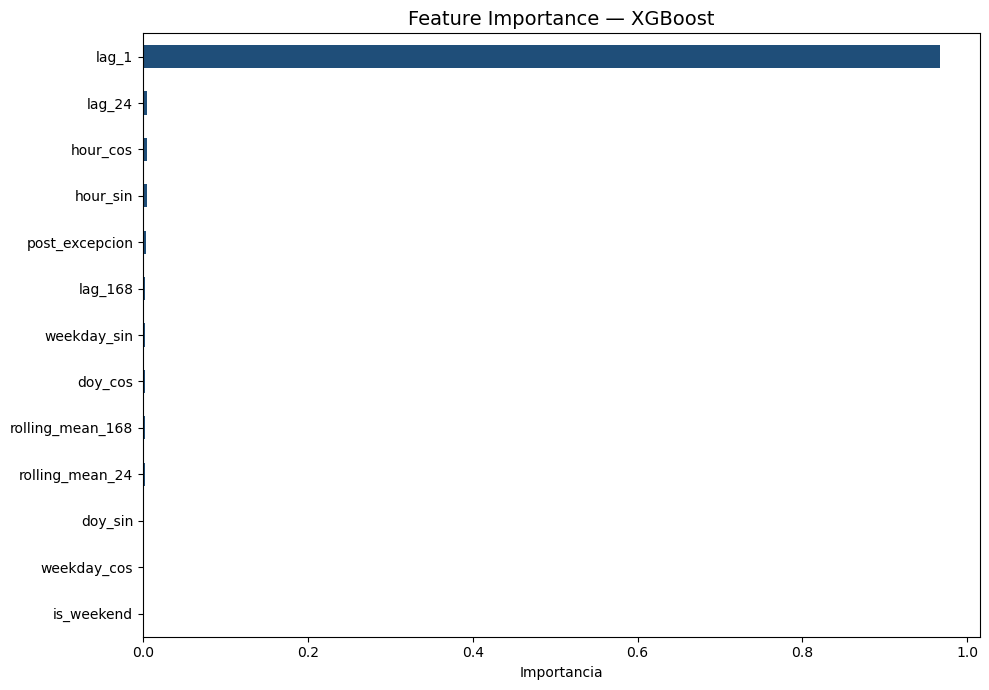

In [ ]:
importance = pd.Series(xgb.feature_importances_, index=features).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
importance.plot(kind="barh", ax=ax, color="#1F4E79")
ax.set_title("Feature Importance — XGBoost", fontsize=14)
ax.set_xlabel("Importancia")
plt.tight_layout()
plt.savefig("../outputs/feature_importance_xgboost.png", dpi=150)
plt.show()

In [12]:
print(importance.sort_values(ascending=False))

lag_1               0.967027
lag_24              0.005185
hour_cos            0.004817
hour_sin            0.004490
post_excepcion      0.003822
lag_168             0.002810
weekday_sin         0.002601
doy_cos             0.002403
rolling_mean_168    0.002037
rolling_mean_24     0.001899
doy_sin             0.001511
weekday_cos         0.001399
is_weekend          0.000000
dtype: float32


Es bastante llamativo. El mayor predictor del precio es la hora anterior, lo cual refleja una autocorrelación enorme y una gran inercia. Las demás solo complementan (24h, la hora que es, etc). Mención especial para 'post_exception', complementa con mas importancia que el dia de la semana en si o la semana anterior (lag_168). 
La inclusión de datos de generación de energia o condiciones metereológicas seguramente influyeran mas en predicción y arrebatarían algo de importancia al lag_1.

#### Comparativa modelos

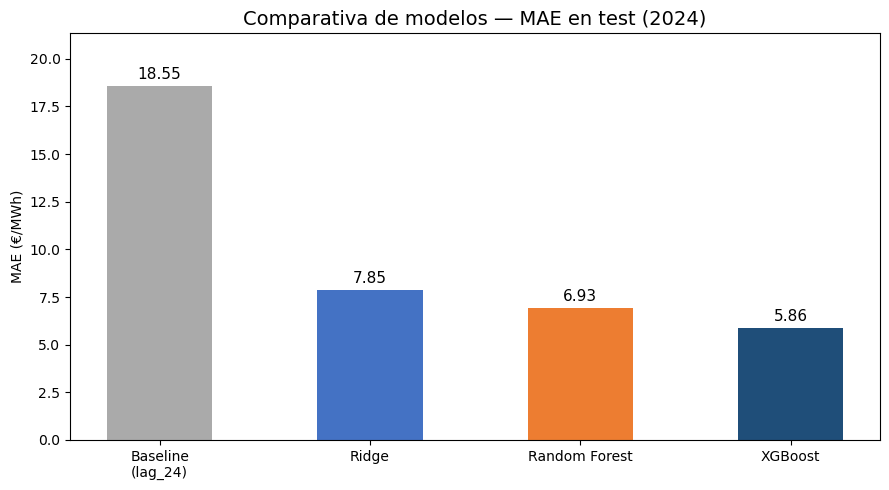

In [13]:
models = ["Baseline\n(lag_24)", "Ridge", "Random Forest", "XGBoost"]
maes = [baseline_mae, ridge_mae, rf_mae, xgb_mae]
colors = ["#AAAAAA", "#4472C4", "#ED7D31", "#1F4E79"]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(models, maes, color=colors, width=0.5)
ax.bar_label(bars, fmt="%.2f", padding=3, fontsize=11)
ax.set_title("Comparativa de modelos — MAE en test (2024)", fontsize=14)
ax.set_ylabel("MAE (€/MWh)")
ax.set_ylim(0, max(maes) * 1.15)
plt.tight_layout()
plt.savefig("../outputs/comparativa_modelos.png", dpi=150)
plt.show()

### Conclusiones

XGBoost obtiene el mejor resultado con un MAE de 5.86 €/MWh sobre el conjunto 
de test (año 2024 completo), lo que representa un error relativo de aproximadamente 
el 9% sobre el precio medio. Todos los modelos superan ampliamente el baseline 
de 18.55 €/MWh, confirmando que las features engineered aportan información 
predictiva real.

El análisis de feature importance revela que el precio de la hora anterior (lag_1) 
domina la predicción con una importancia de 0.97, reflejando la alta autocorrelación 
del mercado eléctrico español. La variable de régimen post_excepcion confirma que 
el cambio estructural del mercado tras la Excepción Ibérica de 2022 es 
estadísticamente relevante para la predicción.

Como próximos pasos, la incorporación de datos de generación renovable (solar, 
eólica, hidráulica) de ESIOS y datos meteorológicos de Open-Meteo permitirá 
reducir la dependencia del lag_1 y mejorar la capacidad predictiva del modelo 
en horizontes más largos.

In [14]:
# Guardemos los modelos
import joblib

models_dir = os.path.join(base_dir, "models")
os.makedirs(models_dir, exist_ok=True)

joblib.dump(ridge, os.path.join(models_dir, "ridge.pkl"))
joblib.dump(rf, os.path.join(models_dir, "random_forest.pkl"))
joblib.dump(xgb, os.path.join(models_dir, "xgboost.pkl"))

['c:\\Users\\marco\\OneDrive\\Escritorio\\Mis_proyectitos\\electricity-price-forecast\\models\\xgboost.pkl']